# Thong ke dataset harmful_videos

Notebook nay thong ke tong quan bo du lieu trong file CSV va thu muc video do ban tu paste vao Cell 2.
Ban chi can cap nhat:
- `csv_path`: path den file CSV
- `video_dir`: path den thu muc video

Notebook se su dung 2 config nay cho toan bo cac cell phia duoi.

In [2]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
plt.style.use('ggplot')

# Paste path vao day
# 1) Path den file CSV
# csv_path = Path(r"D:\Workspace\project-setup\HF-DATASET-SOMET\HF-DATASET-SOMET\label.csv")
csv_path = Path(r"D:\Workspace\project-setup\convert-label\harmful_videos-converted.csv")

# 2) Path den thu muc chua video
# video_dir = Path(r"D:\Workspace\project-setup\HF-DATASET-SOMET\HF-DATASET-SOMET\videos")
video_dir = Path(r"D:\Workspace\project-setup\HF-DATASET-SOMET\all_videos")

if str(csv_path).strip() == 'PASTE_YOUR_CSV_PATH_HERE':
    raise ValueError('Hay dan path CSV vao bien csv_path truoc khi chay notebook.')
if str(video_dir).strip() == 'PASTE_YOUR_VIDEO_DIR_HERE':
    raise ValueError('Hay dan path thu muc video vao bien video_dir truoc khi chay notebook.')

if csv_path.is_dir():
    csv_path = csv_path / 'harmful_videos_under_sampling.csv'

if not csv_path.exists():
    raise FileNotFoundError(f'Khong tim thay file CSV: {csv_path}')
if not video_dir.exists():
    raise FileNotFoundError(f'Khong tim thay thu muc video: {video_dir}')

root = csv_path.parent
classes_path = root / 'classes.txt'

if not classes_path.exists():
    raise FileNotFoundError(f'Khong tim thay file classes.txt: {classes_path}')

df = pd.read_csv(csv_path)
with open(classes_path, 'r', encoding='utf-8') as f:
    classes = [line.strip() for line in f if line.strip()]

print('CSV path   :', csv_path)
print('Video dir  :', video_dir)
print('Classes    :', len(classes))
print('Shape      :', df.shape)
display(df.head())

CSV path   : D:\Workspace\project-setup\convert-label\harmful_videos-converted.csv
Video dir  : D:\Workspace\project-setup\HF-DATASET-SOMET\all_videos
Classes    : 7
Shape      : (6285, 8)


,filename,information_harm,sexual_harm,psychological_harm,hate_harassment_harm,clickbait_harm,addictive_harm,physical_harm
0,20260402174909.mp4,0,0,0,0,1,0,0
1,20260402174915.mp4,0,0,0,0,1,0,0
2,20260402174931.mp4,0,0,0,0,1,0,0
3,20260402174935.mp4,0,0,0,0,1,0,0
4,20260402174941.mp4,0,0,0,0,1,0,0


In [7]:
# Kiem tra cot nhan
label_cols = [c for c in classes if c in df.columns]
missing_labels = [c for c in classes if c not in df.columns]
extra_cols = [c for c in df.columns if c not in ['filename'] + classes]

n_samples = len(df)
n_unique_files = df['filename'].nunique() if 'filename' in df.columns else np.nan
n_duplicate_files = n_samples - n_unique_files if pd.notna(n_unique_files) else np.nan

overview = pd.DataFrame({
    'metric': [
        'n_samples',
        'n_unique_filenames',
        'n_duplicated_filenames',
        'n_label_columns_in_csv',
        'n_labels_from_classes_txt',
        'n_missing_labels_in_csv',
        'n_extra_columns_in_csv'
    ],
    'value': [
        n_samples,
        n_unique_files,
        n_duplicate_files,
        len(label_cols),
        len(classes),
        len(missing_labels),
        len(extra_cols)
    ]
})

display(overview)
if missing_labels:
    print('Missing labels:', missing_labels)
if extra_cols:
    print('Extra columns :', extra_cols)

,metric,value
0,n_samples,6285
1,n_unique_filenames,6285
2,n_duplicated_filenames,0
3,n_label_columns_in_csv,7
4,n_labels_from_classes_txt,7
5,n_missing_labels_in_csv,0
6,n_extra_columns_in_csv,0


In [8]:
# Chuan hoa ve nhi phan de thong ke prevalence
label_df_raw = df[label_cols].copy()
label_df_bin = (label_df_raw > 0).astype(int)

normal_mask = label_df_bin.sum(axis=1).eq(0)
normal_count = int(normal_mask.sum())

label_count = label_df_bin.sum(axis=0).sort_values(ascending=False)
label_count = pd.concat([pd.Series({'normal_content': normal_count}), label_count]).sort_values(ascending=False)
label_prevalence = (label_count / n_samples).sort_values(ascending=False)

label_stats = pd.DataFrame({
    'label_count': label_count,
    'prevalence': label_prevalence
})

display(label_stats)
print('So mau normal content (khong duoc gan nhan nao):', normal_count)
print('So mau co it nhat 1 nhan               :', int((~normal_mask).sum()))

,label_count,prevalence
normal_content,1620,0.257757
addictive_harm,1142,0.181702
physical_harm,1080,0.171838
psychological_harm,1003,0.159586
clickbait_harm,828,0.131742
hate_harassment_harm,541,0.086078
sexual_harm,533,0.084805
information_harm,269,0.042800


So mau normal content (khong duoc gan nhan nao): 1620
So mau co it nhat 1 nhan               : 4665


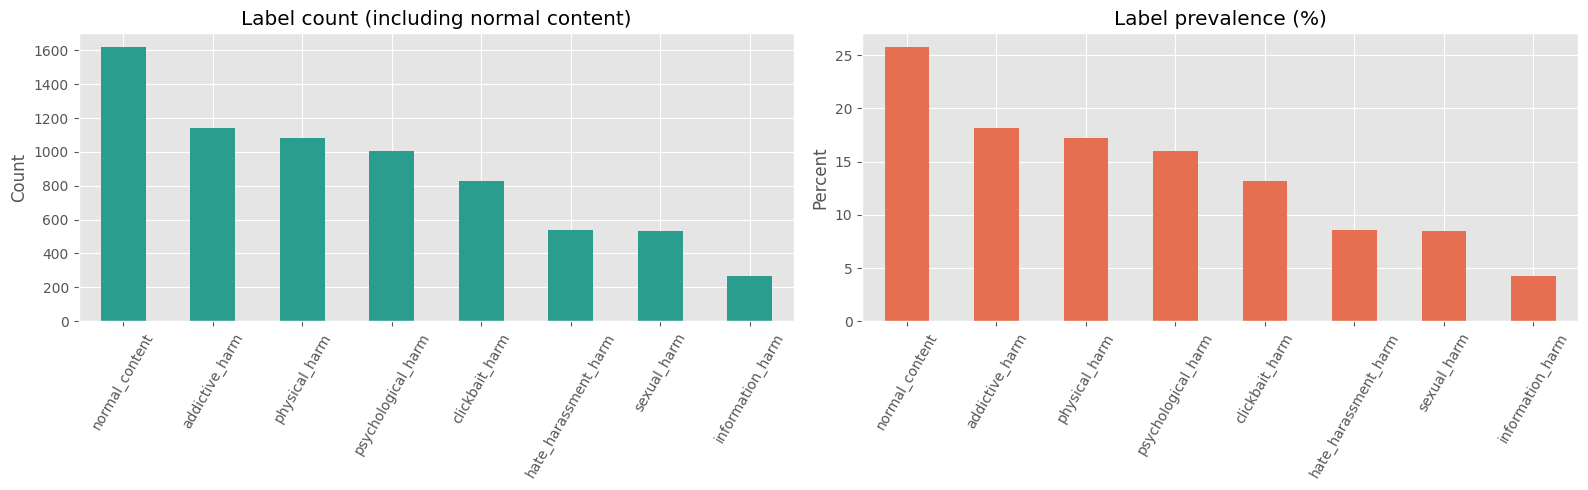

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

label_count.plot(kind='bar', ax=axes[0], color='#2a9d8f')
axes[0].set_title('Label count (including normal content)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=60)

(label_prevalence * 100).plot(kind='bar', ax=axes[1], color='#e76f51')
axes[1].set_title('Label prevalence (%)')
axes[1].set_ylabel('Percent')
axes[1].tick_params(axis='x', rotation=60)

plt.tight_layout()
plt.show()

,n_labels,n_samples,ratio,file_name
0,0,1620,0.257757,"20260402173613.mp4, 20260402173623.mp4, 202604..."
1,1,3937,0.626412,"20260402174909.mp4, 20260402174915.mp4, 202604..."
2,2,725,0.115354,"20260403095355.mp4, 20260403095411.mp4, 202604..."
3,3,3,0.000477,"7f3d8289-7527107029857488142.mp4, 2ccec372-755..."


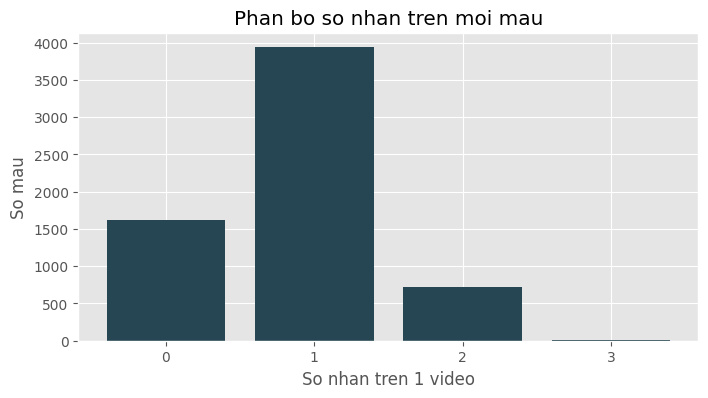

In [12]:
# Phan bo so nhan tren moi video
num_labels_per_sample = label_df_bin.sum(axis=1)
dist_num_labels = num_labels_per_sample.value_counts().sort_index()

# Gom filename theo tung nhom so nhan (chi hien thi toi da 10 ten/nhom)
filename_col = 'filename' if 'filename' in df.columns else None
if filename_col is None:
    filename_col = 'file_name' if 'file_name' in df.columns else None

if filename_col is not None:
    filenames_by_label_count = (
        pd.DataFrame({
            'n_labels': num_labels_per_sample,
            'file_name': df[filename_col].astype(str)
        })
        .groupby('n_labels')['file_name']
        .apply(lambda s: ', '.join(s.head(10)))
    )
    stats_table = pd.DataFrame({
        'n_labels': dist_num_labels.index,
        'n_samples': dist_num_labels.values,
        'ratio': dist_num_labels.values / n_samples,
        'file_name': [filenames_by_label_count.get(k, '') for k in dist_num_labels.index],
    })
else:
    stats_table = pd.DataFrame({
        'n_labels': dist_num_labels.index,
        'n_samples': dist_num_labels.values,
        'ratio': dist_num_labels.values / n_samples,
        'file_name': ['(khong tim thay cot filename/file_name trong df)'] * len(dist_num_labels),
    })

display(stats_table)

plt.figure(figsize=(8, 4))
plt.bar(dist_num_labels.index.astype(str), dist_num_labels.values, color='#264653')
plt.title('Phan bo so nhan tren moi mau')
plt.xlabel('So nhan tren 1 video')
plt.ylabel('So mau')
plt.show()

In [6]:
# Hien thi danh sach ten file co dung 3 nhan + nhan duoc gan

# Chon DataFrame nguon cho nhan
source_df = label_df_bin if 'label_df_bin' in globals() else df
base_df = df if 'df' in globals() else source_df

# Xac dinh cot ten file tu DataFrame tong
if 'filename_col' in globals() and filename_col in base_df.columns:
    file_col = filename_col
else:
    fallback_cols = ['file_name', 'filename', 'name', 'video_name', 'video_id']
    file_col = next((c for c in fallback_cols if c in base_df.columns), None)

# Xac dinh cac cot nhan
if 'label_cols' in globals() and set(label_cols).issubset(base_df.columns):
    labels = label_cols
else:
    labels = [
        c for c in source_df.columns
        if source_df[c].dropna().isin([0, 1]).all()
    ]

if not labels:
    raise ValueError('Khong tim thay cot nhan de tinh so luong nhan.')

label_matrix = source_df[labels] if set(labels).issubset(source_df.columns) else base_df[labels]
label_matrix = label_matrix.fillna(0).astype(int).reset_index(drop=True)

# Lay series ten file tu cot file hoac index
if file_col and file_col in source_df.columns:
    file_series = source_df[file_col].reset_index(drop=True)
elif file_col and file_col in base_df.columns and len(base_df) == len(label_matrix):
    file_series = base_df[file_col].reset_index(drop=True)
elif len(source_df.index) == len(label_matrix):
    file_series = source_df.index.to_series().reset_index(drop=True)
else:
    raise ValueError('Khong the dong bo ten file voi bang nhan. Hay kiem tra du lieu nguon.')

# Loc cac dong co dung 3 nhan
label_count = label_matrix.sum(axis=1)
mask_3_labels = label_count == 3

# Tao chuoi nhan da duoc gan cho tung dong
assigned_labels = label_matrix.apply(
    lambda row: ', '.join([lbl for lbl, v in row.items() if v == 1]),
    axis=1
)

display_name = file_col if file_col else 'file_name'
result_df = pd.DataFrame({
    display_name: file_series,
    'n_labels': label_count,
    'assigned_labels': assigned_labels,
})

result_df = (
    result_df.loc[mask_3_labels]
    .dropna(subset=[display_name])
    .assign(**{display_name: lambda d: d[display_name].astype(str)})
    .drop_duplicates(subset=[display_name])
    .sort_values(by=display_name)
    .reset_index(drop=True)
)

print(f'So file co dung 3 nhan: {len(result_df)}')
display(result_df)

So file co dung 3 nhan: 3


,filename,n_labels,assigned_labels
0,2ccec372-7555158582556380446.mp4,3,"psychological_harm, addictive_harm, physical_harm"
1,6d61cb6c-glambing_88996.mp4,3,"sexual_harm, psychological_harm, addictive_harm"
2,7f3d8289-7527107029857488142.mp4,3,"psychological_harm, addictive_harm, physical_harm"


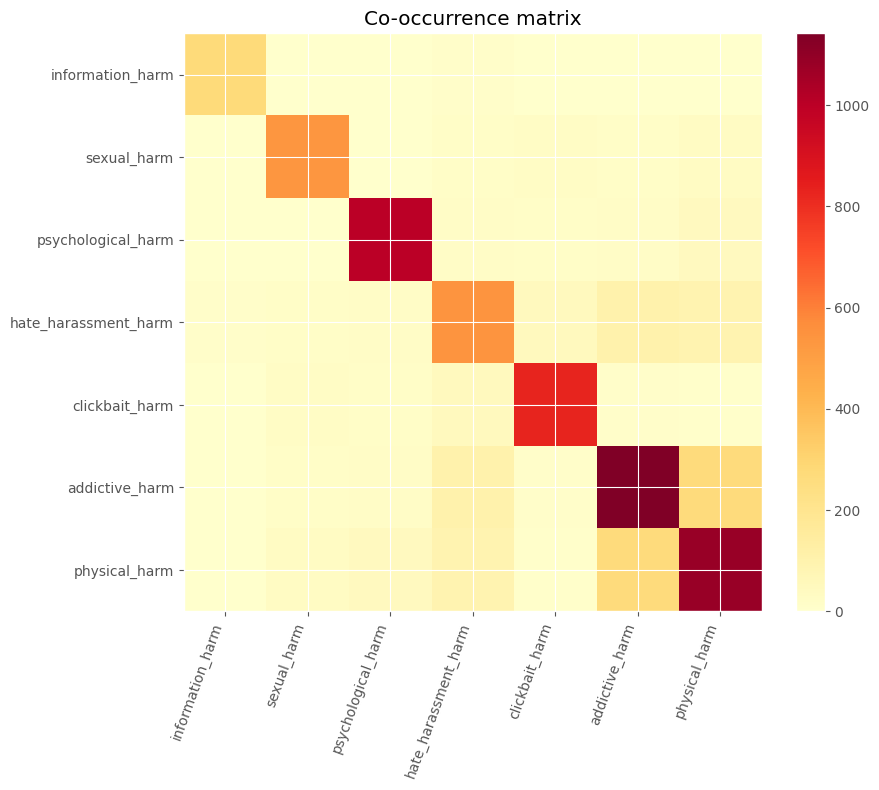

,information_harm,sexual_harm,psychological_harm,hate_harassment_harm,clickbait_harm,addictive_harm,physical_harm
information_harm,269,4,0,11,1,1,0
sexual_harm,4,533,4,15,25,17,30
psychological_harm,0,4,1003,18,16,22,42
hate_harassment_harm,11,15,18,541,47,106,93
clickbait_harm,1,25,16,47,828,11,7
addictive_harm,1,17,22,106,11,1142,264
physical_harm,0,30,42,93,7,264,1080


In [7]:
# Ma tran dong xuat hien giua cac nhan (dua tren du lieu da nhi phan hoa)
co_mat = label_df_bin.T.dot(label_df_bin)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(co_mat.values, cmap='YlOrRd')
ax.set_xticks(range(len(co_mat.columns)))
ax.set_yticks(range(len(co_mat.index)))
ax.set_xticklabels(co_mat.columns, rotation=70, ha='right')
ax.set_yticklabels(co_mat.index)
ax.set_title('Co-occurrence matrix')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

display(co_mat)

## Thong ke thoi luong video

Cell ben duoi se tinh thoi luong (giay) cho tung video trong dataset, sau do thong ke:
- So video doc duoc / khong doc duoc
- Min, max, trung binh, median, p90, p95
- Histogram phan bo thoi luong
- Top video dai nhat va ngan nhat

Tong so video theo CSV       : 6285
So file ton tai trong folder : 6285
So file thieu               : 0
So video doc duoc duration  : 6285
So video khong doc duoc     : 0


,duration_sec
metric,
count,6285.000000
mean,46.652210
std,45.695414
min,1.040000
50%,29.400000
90%,100.120000
95%,143.306667
max,298.300000


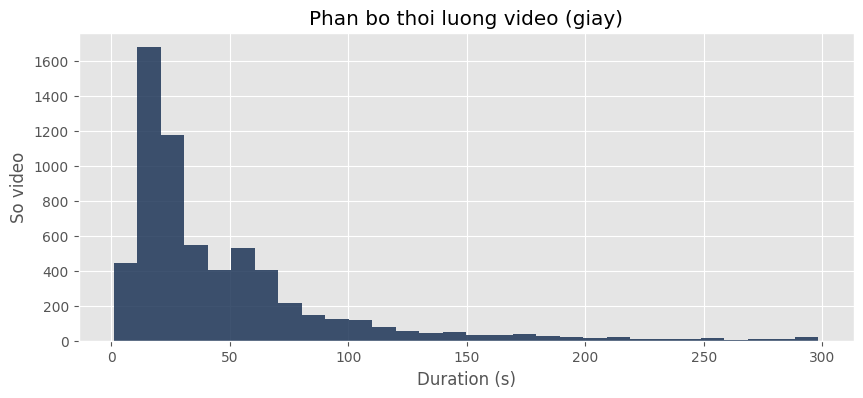

Top 10 video ngan nhat:


,filename,duration_sec
3560,e9bb9fc1-7507662989969919254.mp4,1.040000
5894,60b8b8fb-snaptik.vn_eAVBn.mp4,3.766667
896,20260331144049.mp4,5.033333
4687,36a9b67c-7572807485556378888.mp4,5.041667
5505,33de16c5-Download_50.mp4,5.041667
5301,ad1bb39e-Download_-_2026-01-11T143149.355.mp4,5.066667
332,20260401214832.mp4,5.088422
3500,7a65174e-7480750283828497671.mp4,5.100000
3317,7516566141800680722.mp4,5.100000
1988,7147668777163869483.mp4,5.166667


Top 10 video dai nhat:


,filename,duration_sec
4338,7190a930-toiyeuvietnam2800-2025-12-08_1942-vie...,298.300000
5323,8488670a-Download_-_2026-01-11T145546.327.mp4,298.033333
4278,54cbb7f3-linlinhyeulichsu-2025-03-10_1849-Bac-...,296.833333
1701,20260328102752.mp4,296.333333
4202,5ad9946f-dauan.lichsu-2025-03-28_1223-Chien-di...,296.200000
2819,c01c67ab-7473046336603016466.mp4,296.100000
5438,1d595930-Download_-_2026-01-12T094216.630.mp4,295.900000
26,20260402174228.mp4,295.466667
4507,5837b1d2-7531639687589465351.mp4,293.200000
4204,68b4f1a4-dauan.lichsu-2025-04-30_1916-Chien-di...,293.000000


In [8]:
# Thong ke thoi luong video tu thu muc video_dir
# Yeu cau: opencv-python (cv2)

if not video_dir.exists():
    raise FileNotFoundError(f'Khong tim thay thu muc video: {video_dir}')

try:
    import cv2
except ImportError as e:
    raise ImportError(
        "Chua cai dat opencv-python. Cai dat bang lenh: pip install opencv-python"
    ) from e


def get_duration_seconds(video_path):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return np.nan

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    cap.release()

    if fps is None or fps <= 0 or frame_count is None or frame_count <= 0:
        return np.nan
    return frame_count / fps


# Uu tien dung danh sach filename trong CSV de map dung voi nhan
if 'filename' not in df.columns:
    raise KeyError("CSV khong co cot 'filename' de doi chieu video")

video_df = pd.DataFrame({'filename': df['filename'].astype(str)})
video_df['video_path'] = video_df['filename'].apply(lambda x: video_dir / x)
video_df['exists'] = video_df['video_path'].apply(lambda p: p.exists())
video_df['duration_sec'] = video_df['video_path'].apply(
    lambda p: get_duration_seconds(p) if p.exists() else np.nan
)

n_total = len(video_df)
n_exists = int(video_df['exists'].sum())
n_missing = n_total - n_exists
n_readable = int(video_df['duration_sec'].notna().sum())
n_unreadable = n_exists - n_readable

print(f'Tong so video theo CSV       : {n_total}')
print(f'So file ton tai trong folder : {n_exists}')
print(f'So file thieu               : {n_missing}')
print(f'So video doc duoc duration  : {n_readable}')
print(f'So video khong doc duoc     : {n_unreadable}')

duration_stats = video_df['duration_sec'].describe(percentiles=[0.5, 0.9, 0.95])
duration_stats_df = duration_stats.to_frame(name='duration_sec').rename_axis('metric')
display(duration_stats_df)

# Histogram thoi luong
plt.figure(figsize=(10, 4))
valid_duration = video_df['duration_sec'].dropna()
if len(valid_duration) > 0:
    plt.hist(valid_duration, bins=30, color='#1d3557', alpha=0.85)
    plt.title('Phan bo thoi luong video (giay)')
    plt.xlabel('Duration (s)')
    plt.ylabel('So video')
    plt.show()
else:
    print('Khong co duration hop le de ve histogram.')

# Top ngan nhat / dai nhat
shortest_videos = video_df[['filename', 'duration_sec']].dropna().nsmallest(10, 'duration_sec')
longest_videos = video_df[['filename', 'duration_sec']].dropna().nlargest(10, 'duration_sec')

print('Top 10 video ngan nhat:')
display(shortest_videos)
print('Top 10 video dai nhat:')
display(longest_videos)

In [ ]:
# # Copy cac video dai hon 5 phut vao thu muc review
# import shutil

# if 'video_df' not in globals():
#     raise RuntimeError('Hay chay truoc Cell 9 (Thong ke thoi luong video).')

# review_dir = root / 'videos_need_review'
# review_dir.mkdir(parents=True, exist_ok=True)

# long_videos = (
#     video_df.loc[video_df['duration_sec'] > 180, ['filename', 'video_path', 'duration_sec']]
#     .sort_values('duration_sec', ascending=False)
#     .reset_index(drop=True)
# )

# copied_count = 0
# missing_count = 0
# failed = []

# for _, row in long_videos.iterrows():
#     src = Path(row['video_path'])
#     if not src.exists():
#         missing_count += 1
#         continue

#     dst = review_dir / src.name
#     try:
#         shutil.copy2(src, dst)
#         copied_count += 1
#     except Exception as e:
#         failed.append((src.name, str(e)))

# report_path = review_dir / 'videos_over_300s_report.csv'
# long_videos[['filename', 'duration_sec']].to_csv(report_path, index=False)

# print(f'Thu muc review: {review_dir}')
# print(f'So video > 300s tim thay : {len(long_videos)}')
# print(f'So video copy thanh cong: {copied_count}')
# print(f'So video bi thieu file  : {missing_count}')
# print(f'So video copy loi       : {len(failed)}')
# print(f'Da luu bao cao          : {report_path}')

# if failed:
#     failed_df = pd.DataFrame(failed, columns=['filename', 'error'])
#     display(failed_df)

# # Hien thi nhanh danh sach can review
# preview_n = min(20, len(long_videos))
# print(f'Xem truoc {preview_n} video dau tien can review:')
# display(long_videos[['filename', 'duration_sec']].head(preview_n))

In [5]:
# Cap nhat nhan trong harmful_videos-converted theo project-14
import json
import re

project_path = Path(r"D:\Workspace\project-setup\convert-label\project-14-at-2026-05-10-08-27-9118f939.csv")
if not project_path.exists():
    raise FileNotFoundError(f"Khong tim thay file project-14: {project_path}")

if "label_cols" not in globals():
    if "classes" in globals():
        label_cols = [c for c in classes if c in df.columns]
    else:
        label_cols = [c for c in df.columns if c != "filename"]

if "filename" not in df.columns:
    raise KeyError("CSV khong co cot 'filename' de doi chieu video")

prefix = "/data/upload/14/"
hex8 = re.compile(r"^[0-9a-fA-F]{8}$")

def normalize_project_video(value):
    v = str(value or "").strip()
    if v.startswith(prefix):
        v = v[len(prefix):]
    v = v.lstrip("/").lower()
    parts = v.split("-", 1)
    if len(parts) == 2 and hex8.match(parts[0]):
        v = parts[1]
    return v

def parse_project_label(raw):
    text = str(raw or "").strip()
    if not text or text.lower() in ("update", "delete"):
        return []
    if text.startswith("{") and "choices" in text:
        try:
            obj = json.loads(text)
            choices = obj.get("choices", [])
            labels = [c for c in choices if isinstance(c, str)]
        except json.JSONDecodeError:
            labels = [text]
    else:
        labels = [text]
    return [l for l in labels if l and l.lower() not in ("update", "delete")]

project_df = pd.read_csv(project_path)
project_df["video_norm"] = project_df["video"].apply(normalize_project_video)
project_df["label_list"] = project_df["label"].apply(parse_project_label)

label_map = {}
for _, row in project_df.iterrows():
    key = row["video_norm"]
    if not key:
        continue
    label_map.setdefault(key, set())
    if row["label_list"]:
        label_map[key].update(row["label_list"])

label_cols_local = [c for c in label_cols if c in df.columns]
df_updated = df.copy()
df_updated[label_cols_local] = 0

matched_rows = 0
missing_rows = 0
unknown_labels = set()

for idx, filename in df_updated["filename"].astype(str).str.lower().items():
    labels = label_map.get(filename)
    if labels is None:
        missing_rows += 1
        continue
    matched_rows += 1
    for lbl in labels:
        if lbl in label_cols_local:
            df_updated.at[idx, lbl] = 1
        else:
            unknown_labels.add(lbl)

project_only = set(label_map.keys()) - set(df_updated["filename"].astype(str).str.lower())
output_path = csv_path.with_name(f"{csv_path.stem}_project14.csv")
df_updated.to_csv(output_path, index=False)

print("Da cap nhat label theo project-14")
print("Tong dong trong converted:", len(df_updated))
print("Khong khop filename:", missing_rows)
print("Co trong project-14 nhung khong co trong converted:", len(project_only))
print("Label khong nam trong classes.txt:", sorted(unknown_labels))
print("Da ghi file:", output_path)

# Dung df_updated cho cac cell thong ke tiep theo
df = df_updated

Da cap nhat label theo project-14
Tong dong trong converted: 6285
Khong khop filename: 5810
Co trong project-14 nhung khong co trong converted: 0
Label khong nam trong classes.txt: ['nan']
Da ghi file: D:\Workspace\project-setup\convert-label\harmful_videos-converted_project14.csv


In [3]:
from pathlib import Path
from collections import Counter
import pandas as pd
# Doi chieu 2 nguon: CSV va thu muc video

def normalize_name(value):
    value = str(value or "").strip().lower()
    if not value:
        return ""
    return Path(value).stem

if "df" not in globals():
    df = pd.read_csv(csv_path)

if "classes" not in globals():
    with open(classes_path, "r", encoding="utf-8") as f:
        classes = [line.strip() for line in f if line.strip()]

label_cols = [c for c in classes if c in df.columns] if "classes" in globals() else [c for c in df.columns if c != "filename"]
if "filename" not in df.columns:
    raise KeyError("CSV khong co cot filename")

csv_names = df["filename"].astype(str).map(normalize_name)
video_names = {
    normalize_name(p.name)
    for p in video_dir.rglob("*")
    if p.is_file()
}

csv_only_mask = ~csv_names.isin(video_names)
video_only = sorted(video_names - set(csv_names))
csv_only_df = df.loc[csv_only_mask].copy()

if csv_only_df.empty:
    print("Khong co dong nao trong CSV bi thieu file video tuong ung.")
else:
    def extract_labels(row):
        labels = [col for col in label_cols if col in row.index and row[col] == 1]
        return labels

    csv_only_df["matched_labels"] = csv_only_df.apply(extract_labels, axis=1)
    csv_only_df["label_count"] = csv_only_df["matched_labels"].map(len)

    print("Tong so dong trong CSV:", len(df))
    print("So file video tim thay:", len(video_names))
    print("So dong chi co trong CSV:", len(csv_only_df))
    print("So file chi co trong thu muc video:", len(video_only))
    print()
    print("Top nhan cua cac dong bi lech:")
    label_counter = Counter(lbl for labels in csv_only_df["matched_labels"] for lbl in labels)
    print(label_counter.most_common(20))
    print()
    display(csv_only_df[["filename", "matched_labels", "label_count"]].head(50))

    print("\nCac dong CSV bi lech nhung co nhan da gan truoc do:")
    for _, row in csv_only_df[["filename", "matched_labels"]].head(30).iterrows():
        print(f"- {row['filename']}: {row['matched_labels']}")

if video_only:
    print("\nVi du file chi co trong thu muc video:")
    for name in video_only[:20]:
        print("-", name)


Khong co dong nao trong CSV bi thieu file video tuong ung.

Vi du file chi co trong thu muc video:
- 0089f0f1-7615579145497627922
- 00b77a0e-7527305142773796103
- 032160d2-7601040208083176712
- 037a4053-7601208962817608974
- 03c1451a-7574568055120874774
- 0415a999-7583254268883389709
- 04edd0db-7582459598653623574
- 05020191-7616231034681675030
- 058a0009-7478693258596535574
- 06b14095-7542339549867937054
- 06c20b49-7572977000084688150
- 074b2995-7593194016473091336
- 074b2e9e-7603835690039725325
- 081c2bd5-download_-_2026-01-11t150611.652
- 08413b8d-7585281891566177556
- 084add4e-7540219810244807944
- 084e0947-download_-_2026-01-11t142530.818
- 0953a213-download_19
- 0962ac31-7558018207253138719
- 0997e78f-7555334001234300161
